In [21]:
# Imports ----------------------------------------------------
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

In [22]:
# OMERO Connection --------------------------------------------
from omero.gateway import BlitzGateway
from omero.model import PolygonI, RoiI
from omero.rtypes import rstring

conn = BlitzGateway("savannahduenweg", "Jasper100308#", host="wss://wsi.lavlab.mcw.edu/omero-wss", port=443, secure=True)
conn.connect()
conn.c.enableKeepAlive(60000000)

In [23]:
# Configuration ----------------------------------------------------
CSV_PATH = "/Volumes/Siren/Prostate_Analyses/SD_Assorted/2025/Prostate/AnnotationDifference/reannot_key-2.csv"
ANNOTATION_PATH = Path("/Volumes/Siren/Prostate_data/1106/Hist/6/Huron/N106_S06_HE_annot2.jpeg")

# Define Omero Color Key
COLOR_PALETTE = {
    (25,20,255): "Seminal Vesicles",
    (0,0,0): "Atrophy",
    (255,122,0): "HGPIN",
    (48,255,50): "G3",
    (255,250,20): "G4NC",
    (254,22,255): "G4CG",
    (33,255,255): "G5",
}

COLOR_TOLERANCE = 10
MIN_AREA = 25 # adjust as needed

# Polygon simplification
# Options
#   1. Fixed pixels:
#           SIMPLIFY_MODE = "fixed"
#           SIMPLIFY_EPSILON = 1.0
#   2. Percentage of perimeter:
#           SIMPLIFY_MODE = "relative"
#           SIMPLIFY_EPSILON = 0.001 # adjust as needed

# Try relative to start because ROI sizes vary greatly
SIMPLIFY_MODE = "relative"
SIMPLIFY_EPSILON = 0.001

# Debugging parameters
SAVE_PREVIEW = True
SHOW_PREVIEW = True

# Visulization parameters
# Maximum width or height of each preview panel.
PREVIEW_MAX_DIMENSION = 1800
PREVIEW_DPI = 120
DRAW_ROI_LABELS = True

# Define configuration dictionaries
EXTRACTION_CONFIG = {
    "color_palette": COLOR_PALETTE,
    "color_tolerance": COLOR_TOLERANCE,
    "min_area": MIN_AREA,
    "simplify_mode": SIMPLIFY_MODE,
    "simplify_epsilon": SIMPLIFY_EPSILON,
}

PREVIEW_CONFIG = {
    "save_preview": SAVE_PREVIEW,
    "show_preview": SHOW_PREVIEW,
    "max_dimension": PREVIEW_MAX_DIMENSION,
    "dpi": PREVIEW_DPI,
    "draw_roi_labels": DRAW_ROI_LABELS,
}


In [24]:
# Image Utilities ------------------------------------------------------

def read_annotation(path):
    """
    Load an annotation image as an RGB uint8 NumPy array.

    Parameters
    ----------
    path : str or pathlib.Path
        Path to the annotation JPEG.

    Returns
    -------
    numpy.ndarray
        RGB image with shape (height, width, 3).
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Annotation image not found: {path}")

    try:
        annotation = np.asarray(Image.open(path).convert("RGB"))
    except Exception as exc:
        raise RuntimeError(
            f"Could not read annotation image: {path}"
        ) from exc

    if annotation.ndim != 3 or annotation.shape[2] != 3:
        raise ValueError(
            "Expected an RGB image with shape (height, width, 3), "
            f"but received {annotation.shape}."
        )

    if annotation.dtype != np.uint8:
        annotation = annotation.astype(np.uint8)

    height, width, channels = annotation.shape

    print("=" * 100)
    print("Loaded annotation")
    print(f"Path:     {path}")
    # print(f"Width:    {width:,} pixels")
    # print(f"Height:   {height:,} pixels")
    # print(f"Channels: {channels}")
    # print(f"Data type: {annotation.dtype}")
    print("-" * 70)

    return annotation
    
def color_mask(image, target_color, tolerance):
    """
    Create a binary mask for pixels near a target RGB color.

    A pixel is accepted when every RGB channel differs from the target
    by no more than the specified tolerance.

    Parameters
    ----------
    image : numpy.ndarray
        RGB uint8 image.
    target_color : tuple[int, int, int]
        Target RGB color.
    tolerance : int
        Maximum difference allowed in each RGB channel.

    Returns
    -------
    numpy.ndarray
        Boolean mask with shape (height, width).
    """
    if tolerance < 0:
        raise ValueError("Color tolerance cannot be negative.")

    target = np.asarray(target_color, dtype=np.int16)

    if target.shape != (3,):
        raise ValueError(
            f"Expected an RGB tuple with three values, got {target_color}."
        )

    difference = np.abs(image.astype(np.int16) - target)

    return np.all(difference <= tolerance, axis=2)

def color_mask(image, target_color, tolerance):
    """
    Create a binary mask for pixels near a target RGB color.

    A pixel is accepted when every RGB channel differs from the target
    by no more than the specified tolerance.

    Parameters
    ----------
    image : numpy.ndarray
        RGB uint8 image.
    target_color : tuple[int, int, int]
        Target RGB color.
    tolerance : int
        Maximum difference allowed in each RGB channel.

    Returns
    -------
    numpy.ndarray
        Boolean mask with shape (height, width).
    """
    if tolerance < 0:
        raise ValueError("Color tolerance cannot be negative.")

    target = np.asarray(target_color, dtype=np.int16)

    if target.shape != (3,):
        raise ValueError(
            f"Expected an RGB tuple with three values, got {target_color}."
        )

    difference = np.abs(image.astype(np.int16) - target)

    return np.all(difference <= tolerance, axis=2)

def calculate_centroid(contour):
    """
    Calculate a contour centroid.

    Returns
    -------
    tuple[float | None, float | None]
        Centroid coordinates. Returns (None, None) for a degenerate contour.
    """
    moments = cv2.moments(contour)

    if moments["m00"] == 0:
        return None, None

    cx = moments["m10"] / moments["m00"]
    cy = moments["m01"] / moments["m00"]

    return float(cx), float(cy)

def simplify_contour(contour):
    """
    Simplify a contour using cv2.approxPolyDP.

    Returns
    -------
    numpy.ndarray
        Simplified OpenCV contour.
    """
    if SIMPLIFY_MODE == "fixed":
        epsilon = float(SIMPLIFY_EPSILON)

    elif SIMPLIFY_MODE == "relative":
        perimeter = cv2.arcLength(contour, closed=True)
        epsilon = float(SIMPLIFY_EPSILON) * perimeter

    else:
        raise ValueError(
            "SIMPLIFY_MODE must be either 'fixed' or 'relative'."
        )

    return cv2.approxPolyDP(
        contour,
        epsilon=epsilon,
        closed=True,
    )

In [25]:
# ROI Extraction ------------------------------------------------------

def extract_rois(annotation, extraction_config):
    """
    Extract polygon contours for each annotation color.

    Parameters
    ----------
    annotation : numpy.ndarray
        RGB annotation image.
    extraction_config : dict
        Configuration dictionary containing:
            - color_palette: dict[tuple[int, int, int], str]
                Mapping of RGB colors to class labels.
            - color_tolerance: int
                Maximum difference allowed in each RGB channel.
            - min_area: float
                Minimum area for a contour to be accepted.
            - simplify_mode: str
                Either "fixed" or "relative" for contour simplification.
            - simplify_epsilon: float
                Epsilon value for contour simplification.

    Returns
    -------
    tuple[list[dict], list[dict]]
        rois:
            One dictionary per accepted ROI.

        class_diagnostics:
            Per-class information including pixel counts and contour
            filtering statistics.
    """
    rois = []
    class_diagnostics = []

    print("\nExtracting ROIs")
    print("-" * 70)

    for color, label in extraction_config["color_palette"].items():
        mask = color_mask(
            image=annotation,
            target_color=color,
            tolerance=extraction_config["color_tolerance"],
        )

        matching_pixels = int(np.count_nonzero(mask))

        contours, _ = cv2.findContours(
            mask.astype(np.uint8),
            mode=cv2.RETR_EXTERNAL,
            method=cv2.CHAIN_APPROX_SIMPLE,
        )

        raw_contour_count = len(contours)
        area_rejected_count = 0
        invalid_polygon_count = 0
        accepted_count = 0

        print(f"{label}")

        # print("-" * 40)
        # print(f"RGB color:             {color}")
        # print(f"Matching pixels:       {matching_pixels:,}")
        # print(f"Raw contours:          {raw_contour_count:,}")

        for raw_contour in contours:
            raw_area = float(cv2.contourArea(raw_contour))

            if raw_area < MIN_AREA:
                area_rejected_count += 1
                continue

            simplified_contour = simplify_contour(raw_contour)

            # A valid polygon needs at least three vertices.
            if len(simplified_contour) < 3:
                invalid_polygon_count += 1
                continue

            simplified_area = float(
                cv2.contourArea(simplified_contour)
            )

            cx, cy = calculate_centroid(simplified_contour)

            rois.append(
                {
                    "id": None,
                    "label": label,
                    "color": tuple(int(value) for value in color),
                    "contour": simplified_contour,
                    "area": simplified_area,
                    "raw_area": raw_area,
                    "centroid": (cx, cy),
                    "raw_vertices": int(len(raw_contour)),
                    "vertices": int(len(simplified_contour)),
                }
            )

            accepted_count += 1

        class_diagnostics.append(
            {
                "label": label,
                "color": color,
                "matching_pixels": matching_pixels,
                "raw_contours": raw_contour_count,
                "area_rejected": area_rejected_count,
                "invalid_polygons": invalid_polygon_count,
                "accepted": accepted_count,
            }
        )

        # print(f"Rejected by area:      {area_rejected_count:,}")
        # print(f"Invalid after simplify:{invalid_polygon_count:>7,}")
        # print(f"Accepted ROIs:         {accepted_count:,}")

    rois = sort_and_assign_ids(rois)

    print(f"Total accepted ROIs: {len(rois):,}")
    return rois, class_diagnostics


def sort_and_assign_ids(rois):
    """
    Sort ROIs consistently and assign class-specific IDs.

    Example IDs:
        G3-01
        G3-02
        G4NC-01
    """
    def sort_key(roi):
        cx, cy = roi["centroid"]

        # Place invalid centroids at the end.
        sort_x = float("inf") if cx is None else cx
        sort_y = float("inf") if cy is None else cy

        return (
            roi["label"],
            sort_y,
            sort_x,
        )

    sorted_rois = sorted(rois, key=sort_key)

    label_counts = defaultdict(int)

    for roi in sorted_rois:
        label = roi["label"]
        label_counts[label] += 1

        roi["id"] = f"{label}-{label_counts[label]:02d}"

    return sorted_rois

In [26]:
# Reporting -----------------------------------------------------------

def summarize_rois(rois):
    """
    Print ROI count, area, and vertex statistics by annotation class.
    """
    # print("\nROI Summary")
    # print("-" * 70)

    if not rois:
        print("No ROIs were detected.")
        return

    grouped = defaultdict(list)

    for roi in rois:
        grouped[roi["label"]].append(roi)

    header = (
        f"{'Class':<18}"
        f"{'Count':>8}"
        f"{'Mean area':>14}"
        f"{'Min area':>14}"
        f"{'Max area':>14}"
        f"{'Mean vertices':>17}"
        f"{'Max vertices':>15}"
    )

    # print(header)
    # print("-" * len(header))

    for label in sorted(grouped):
        class_rois = grouped[label]

        areas = np.asarray(
            [roi["area"] for roi in class_rois],
            dtype=float,
        )

        vertices = np.asarray(
            [roi["vertices"] for roi in class_rois],
            dtype=float,
        )

        # print(
        #     f"{label:<18}"
        #     f"{len(class_rois):>8,}"
        #     f"{np.mean(areas):>14,.1f}"
        #     f"{np.min(areas):>14,.1f}"
        #     f"{np.max(areas):>14,.1f}"
        #     f"{np.mean(vertices):>17,.1f}"
        #     f"{int(np.max(vertices)):>15,}"
        # )

    # print("-" * len(header))
    # print(f"{'TOTAL':<18}{len(rois):>8,}")


def print_roi_details(rois, maximum=None):
    """
    Print details for individual ROIs.

    Parameters
    ----------
    rois : list[dict]
        Extracted ROI records.
    maximum : int or None
        Maximum number of ROIs to print. None prints every ROI.
    """
    # print("\nIndividual ROI Details")
    # print("=" * 100)

    selected_rois = rois if maximum is None else rois[:maximum]

    for roi in selected_rois:
        cx, cy = roi["centroid"]

        if cx is None:
            centroid_text = "undefined"
        else:
            centroid_text = f"({cx:.1f}, {cy:.1f})"

        # print(
        #     f"{roi['id']:<14}"
        #     f"area={roi['area']:>12,.1f}   "
        #     f"centroid={centroid_text:<24}"
        #     f"vertices={roi['vertices']:>6,}   "
        #     f"raw vertices={roi['raw_vertices']:>6,}"
        # )

    if maximum is not None and len(rois) > maximum:
        print(
            f"Displayed {maximum} of {len(rois)} total ROIs."
        )
    print("-" * 70)

In [27]:
# Visualization ------------------------------------------------------

def preview_rois(
    annotation,
    rois,
    source_path=None,
    save_preview=True,
    show_preview=True,
    max_dimension=PREVIEW_MAX_DIMENSION,
    draw_labels=DRAW_ROI_LABELS,
):
    """
    Create a memory-efficient, downsampled visualization.

    Important:
        Downsampling affects only the preview. The original annotation and
        original-resolution ROI contours remain unchanged for later upload.
    """
    height, width = annotation.shape[:2]

    scale = min(
        1.0,
        max_dimension / max(height, width),
    )

    preview_width = max(1, int(round(width * scale)))
    preview_height = max(1, int(round(height * scale)))

    print("\nCreating preview")
    print("-" * 70)
    print(f"Original size: {width:,} × {height:,}")
    print(
        f"Preview size:  {preview_width:,} × "
        f"{preview_height:,}"
    )
    print(f"Preview scale: {scale:.4f}")

    # INTER_AREA is well suited to shrinking images.
    annotation_preview = cv2.resize(
        annotation,
        dsize=(preview_width, preview_height),
        interpolation=cv2.INTER_AREA,
    )

    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 6),
        dpi=PREVIEW_DPI,
    )

    axes[0].imshow(annotation_preview)
    axes[0].set_title("Original Annotation — Downsampled")
    axes[0].axis("off")

    # Avoid allocating another full-size RGB array.
    axes[1].set_facecolor("white")
    axes[1].set_xlim(0, preview_width)
    axes[1].set_ylim(preview_height, 0)
    axes[1].set_aspect("equal")

    for roi in rois:
        contour = roi["contour"]

        # Scale only the coordinates used for visualization.
        x = contour[:, 0, 0].astype(np.float32) * scale
        y = contour[:, 0, 1].astype(np.float32) * scale

        x_closed = np.append(x, x[0])
        y_closed = np.append(y, y[0])

        normalized_color = (
            np.asarray(roi["color"], dtype=np.float32) / 255.0
        )

        axes[1].plot(
            x_closed,
            y_closed,
            color=normalized_color,
            linewidth=0.8,
        )

        if draw_labels:
            cx, cy = roi["centroid"]

            if cx is not None and cy is not None:
                axes[1].text(
                    cx * scale,
                    cy * scale,
                    roi["id"],
                    fontsize=4,
                    color="black",
                    ha="center",
                    va="center",
                )

    settings_text = (
        f"ROIs: {len(rois):,} | "
        f"Preview scale: {scale:.3f} | "
        f"Tolerance: ±{COLOR_TOLERANCE} | "
        f"Minimum area: {MIN_AREA:g} px²"
    )

    axes[1].set_title(
        "Extracted Polygon Outlines — Downsampled\n"
        + settings_text
    )
    axes[1].axis("off")

    figure.tight_layout()

    preview_path = None

    if save_preview:
        if source_path is None:
            preview_path = Path("roi_preview.jpg")
        else:
            source_path = Path(source_path)
            preview_path = source_path.with_name(
                f"{source_path.stem}_roi_preview.jpg"
            )

        figure.savefig(
            preview_path,
            dpi=PREVIEW_DPI,
            bbox_inches="tight",
            facecolor="white",
            pil_kwargs={
                "quality": 85,
                "optimize": True,
            },
        )

        print(f"Saved preview: {preview_path}")

    if show_preview:
        plt.show()

    # Explicit cleanup is important in notebooks.
    plt.close(figure)
    del annotation_preview

    return preview_path

In [28]:
# Step 1 - Extract ROIs ------------------------------------------------------
def step1_extract_rois(annotation_path, extraction_config, preview_config):
    """
    Extract ROIs from the annotation image.

    Parameters
    ----------
    annotation_path : str or pathlib.Path
        Path to the annotation JPEG.
    extraction_config : dict
        Configuration parameters for ROI extraction.
    preview_config : dict
        Configuration parameters for preview generation.

    Returns
    -------
    tuple[list[dict], list[dict]]
        rois:
            One dictionary per accepted ROI.

        class_diagnostics:
            Per-class information including pixel counts and contour filtering statistics.
    """

    annotation_path = Path(annotation_path)
    if not annotation_path.exists():
        raise FileNotFoundError(f"Annotation image not found: {annotation_path}")

    annotation_img = read_annotation(annotation_path)
    if annotation_img is None:
        raise RuntimeError(f"Failed to read annotation image: {annotation_path}")

    rois, class_diagnostics = extract_rois(
        annotation_img, extraction_config)

    summarize_rois(rois)

    # Change maximum=None to print all ROI details.
    print_roi_details(
        rois,
        maximum=25,
    )

    preview_rois(
        annotation=annotation_img,
        rois=rois,
        source_path=annotation_path,
        save_preview=preview_config["save_preview"],
        show_preview=preview_config["show_preview"],
    )

    if not rois:
        print(
            "\nWARNING: No ROIs were extracted. Check the color palette, "
            "color tolerance, annotation path, and minimum area."
        )

    summary = {
        "class_diagnostics": class_diagnostics,
    }
    
    return rois, summary

Loaded annotation
Path:     /Volumes/Siren/Prostate_data/1106/Hist/6/Huron/N106_S06_HE_annot2.jpeg
----------------------------------------------------------------------

Extracting ROIs
----------------------------------------------------------------------
Seminal Vesicles
Atrophy
HGPIN
G3
G4NC
G4CG
G5
Total accepted ROIs: 36
Displayed 25 of 36 total ROIs.
----------------------------------------------------------------------

Creating preview
----------------------------------------------------------------------
Original size: 11,350 × 16,650
Preview size:  1,227 × 1,800
Preview scale: 0.1081
Saved preview: /Volumes/Siren/Prostate_data/1106/Hist/6/Huron/N106_S06_HE_annot2_roi_preview.jpg


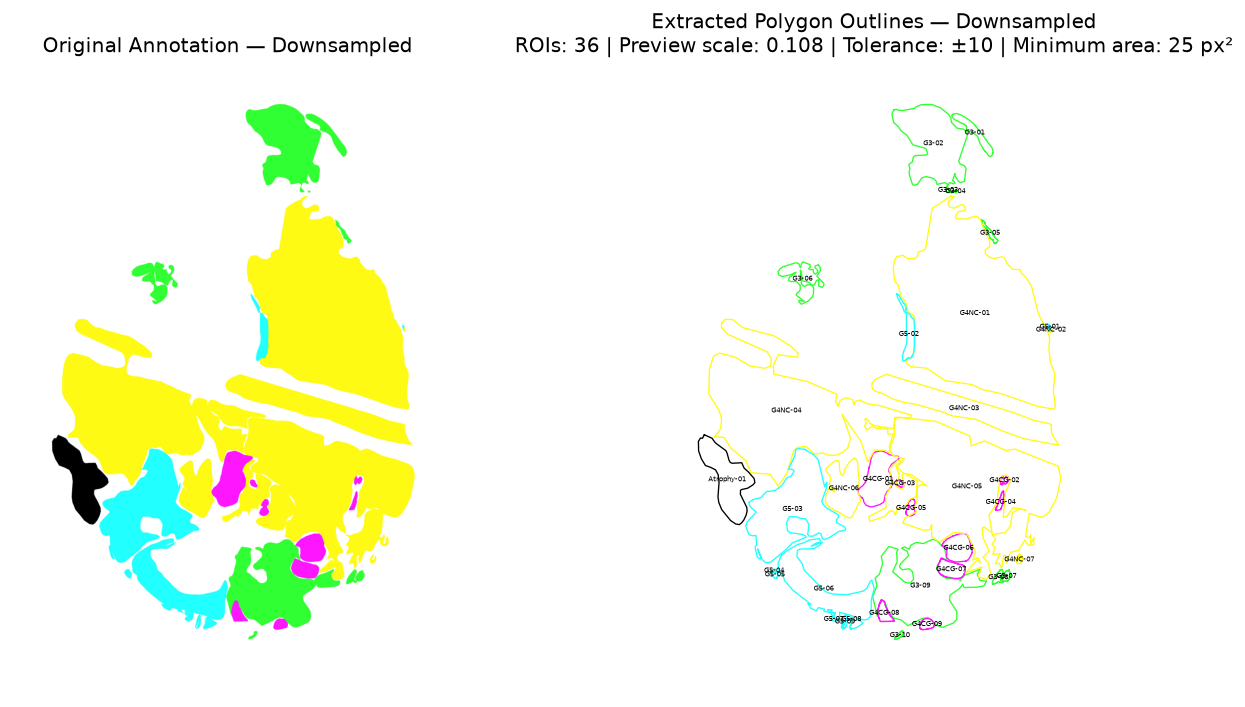

In [29]:
rois, summary = step1_extract_rois(ANNOTATION_PATH, EXTRACTION_CONFIG, PREVIEW_CONFIG)